In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AmazonReviewsPA5") \
    .getOrCreate()

print("Spark session created successfully")
print(spark)

Spark session created successfully


In [3]:
print("PySpark version check:")
print(spark.version)

PySpark version check:
4.0.2


In [5]:
from google.colab import files
files.upload()

Saving normalized_sample.tsv to normalized_sample.tsv


{'normalized_sample.tsv': b'asin\ttitle\timgUrl\tproductURL\tstars\treviews\tprice\tlistPrice\tcategoryName\tisBestSeller\tboughtInLastMonth\trating_type\nB01N6SCF35\tBRITA 075286 Water Filter, Plastic, White\thttps://m.media-amazon.com/images/I/51wpHV+hxzL._AC_UL320_.jpg\thttps://www.amazon.ca/dp/B01N6SCF35\t4.80\t739\t135.98\t0.0\tFiltration\tFalse\t0\tRATED\nB001FGLX72\tBostik Blu-Tack Reusable Adhesive 75g\thttps://m.media-amazon.com/images/I/81APbUgSiML._AC_UL320_.jpg\thttps://www.amazon.ca/dp/B001FGLX72\t4.60\t5971\t12.18\t0.0\tOffice Products\tFalse\t200\tRATED\nB0B1TKDDB6\tTgoon Amplifier Board, Amplifiers Module Durable Good Sound Quality Single Channel for DIY\thttps://m.media-amazon.com/images/I/71GolSm0s8L._AC_UL320_.jpg\thttps://www.amazon.ca/dp/B0B1TKDDB6\t0.00\t0\t15.19\t0.0\tAudio/Video Receivers  Amplifiers\tFalse\t0\tUNRATED\nB0CHM2HRVR\tCATV Security Shield F Connector Removal Tool - Wrench Sleeve Removal, Plated Copper, Compact & Durable, Increased Tightening Levera

In [6]:
df = spark.read.csv(
    "normalized_sample.tsv",
    header=True,
    sep="\t",
    inferSchema=True
)

df.show(5, truncate=False)

+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------+-----------------------------------+-----+-------+------+---------+---------------------------------+------------+-----------------+-----------+
|asin      |title                                                                                                                                                                      |imgUrl                                                        |productURL                         |stars|reviews|price |listPrice|categoryName                     |isBestSeller|boughtInLastMonth|rating_type|
+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------------

In [7]:
print("Number of columns:", len(df.columns))
print(df.columns)

Number of columns: 12
['asin', 'title', 'imgUrl', 'productURL', 'stars', 'reviews', 'price', 'listPrice', 'categoryName', 'isBestSeller', 'boughtInLastMonth', 'rating_type']


In [8]:
df.printSchema()

root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- imgUrl: string (nullable = true)
 |-- productURL: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- reviews: integer (nullable = true)
 |-- price: double (nullable = true)
 |-- listPrice: double (nullable = true)
 |-- categoryName: string (nullable = true)
 |-- isBestSeller: boolean (nullable = true)
 |-- boughtInLastMonth: integer (nullable = true)
 |-- rating_type: string (nullable = true)



In [9]:
print("Row count:", df.count())


Row count: 999


In [10]:
raw = spark.read.text("normalized_sample.tsv")
raw.show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                                                                                                                                                                               |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [12]:
with open("normalized_sample.tsv", "r") as f:
    text = f.read()

text = text.replace("\\t", "\t")

with open("normalized_sample_fixed.tsv", "w") as f:
    f.write(text)

print("Fixed file created")

Fixed file created


In [13]:
df = spark.read.csv(
    "normalized_sample_fixed.tsv",
    header=True,
    sep="\t",
    inferSchema=True
)

df.show(5, truncate=False)

+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------+-----------------------------------+-----+-------+------+---------+---------------------------------+------------+-----------------+-----------+
|asin      |title                                                                                                                                                                      |imgUrl                                                        |productURL                         |stars|reviews|price |listPrice|categoryName                     |isBestSeller|boughtInLastMonth|rating_type|
+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------------

In [14]:
print("Number of columns:", len(df.columns))
print(df.columns)
df.printSchema()
print("Row count:", df.count())

Number of columns: 12
['asin', 'title', 'imgUrl', 'productURL', 'stars', 'reviews', 'price', 'listPrice', 'categoryName', 'isBestSeller', 'boughtInLastMonth', 'rating_type']
root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- imgUrl: string (nullable = true)
 |-- productURL: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- reviews: integer (nullable = true)
 |-- price: double (nullable = true)
 |-- listPrice: double (nullable = true)
 |-- categoryName: string (nullable = true)
 |-- isBestSeller: boolean (nullable = true)
 |-- boughtInLastMonth: integer (nullable = true)
 |-- rating_type: string (nullable = true)

Row count: 999


In [15]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "price_bucket",
    when(col("price") < 10, "LOW")
    .when(col("price") < 30, "MID")
    .when(col("price") < 100, "HIGH")
    .otherwise("PREMIUM")
)

df = df.withColumn(
    "rating_category",
    when(col("stars") >= 4, "GOOD")
    .when(col("stars") >= 2, "AVERAGE")
    .otherwise("LOW_OR_NONE")
)

df.select("stars", "price", "price_bucket", "rating_category", "rating_type").show(10, truncate=False)

+-----+------+------------+---------------+-----------+
|stars|price |price_bucket|rating_category|rating_type|
+-----+------+------------+---------------+-----------+
|4.8  |135.98|PREMIUM     |GOOD           |RATED      |
|4.6  |12.18 |MID         |GOOD           |RATED      |
|0.0  |15.19 |MID         |LOW_OR_NONE    |UNRATED    |
|0.0  |10.05 |MID         |LOW_OR_NONE    |UNRATED    |
|4.5  |31.99 |HIGH        |GOOD           |RATED      |
|4.3  |18.89 |MID         |GOOD           |RATED      |
|0.0  |15.29 |MID         |LOW_OR_NONE    |UNRATED    |
|5.0  |88.98 |HIGH        |GOOD           |RATED      |
|4.7  |72.7  |HIGH        |GOOD           |RATED      |
|4.1  |39.99 |HIGH        |GOOD           |RATED      |
+-----+------+------------+---------------+-----------+
only showing top 10 rows


In [16]:
rating_summary = df.groupBy("rating_type").count().orderBy("count", ascending=False)
rating_summary.show()

+-----------+-----+
|rating_type|count|
+-----------+-----+
|      RATED|  606|
|    UNRATED|  393|
+-----------+-----+



In [17]:
price_bucket_summary = df.groupBy("price_bucket").count().orderBy("count", ascending=False)
price_bucket_summary.show()

+------------+-----+
|price_bucket|count|
+------------+-----+
|         MID|  413|
|        HIGH|  298|
|     PREMIUM|  145|
|         LOW|  143|
+------------+-----+



In [18]:
top_categories = df.groupBy("categoryName").count().orderBy("count", ascending=False)
top_categories.show(10, truncate=False)

+-------------------------------------+-----+
|categoryName                         |count|
+-------------------------------------+-----+
|Handmade Jewellery                   |13   |
|Handmade Clothing, Shoes  Accessories|12   |
|Beauty                               |12   |
|Grocery                              |11   |
|Baby                                 |11   |
|Golf Equipment                       |11   |
|Bath  Body                           |11   |
|Arts  Crafts Supplies                |11   |
|Handmade Kitchen  Dining             |10   |
|Shoe, Jewelry  Watch Accessories     |9    |
+-------------------------------------+-----+
only showing top 10 rows


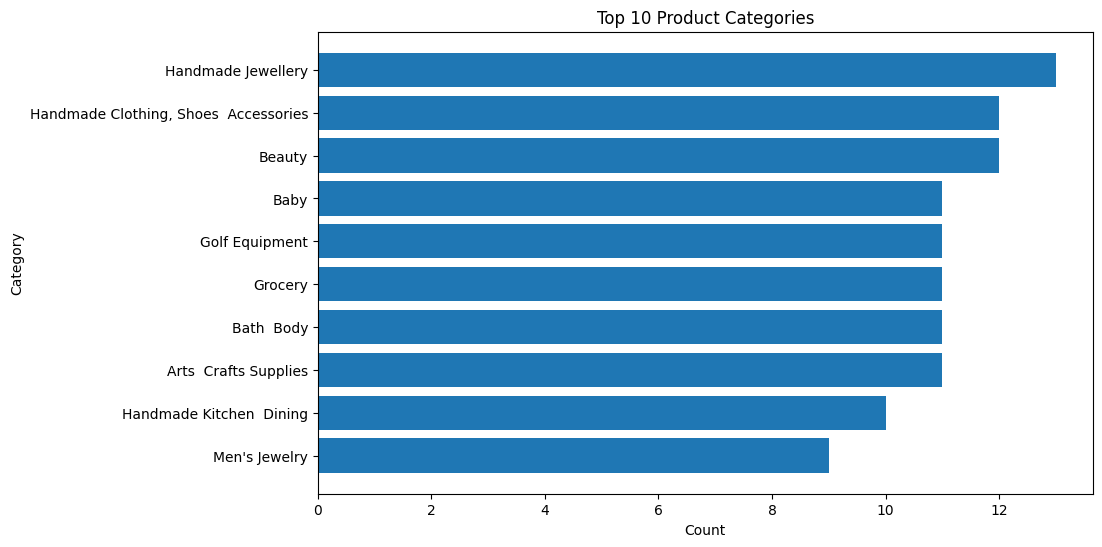

In [19]:
import matplotlib.pyplot as plt

top_categories_pd = top_categories.limit(10).toPandas()

plt.figure(figsize=(10,6))
plt.barh(top_categories_pd["categoryName"], top_categories_pd["count"])
plt.xlabel("Count")
plt.ylabel("Category")
plt.title("Top 10 Product Categories")
plt.gca().invert_yaxis()
plt.show()

In [20]:
rating_summary.coalesce(1).write.mode("overwrite").option("header", True).csv("rating_summary_pyspark")
price_bucket_summary.coalesce(1).write.mode("overwrite").option("header", True).csv("price_bucket_summary_pyspark")
top_categories.limit(10).coalesce(1).write.mode("overwrite").option("header", True).csv("top_categories_pyspark")

In [21]:
rating_summary.show()
price_bucket_summary.show()
top_categories.show(10, truncate=False)

+-----------+-----+
|rating_type|count|
+-----------+-----+
|      RATED|  606|
|    UNRATED|  393|
+-----------+-----+

+------------+-----+
|price_bucket|count|
+------------+-----+
|         MID|  413|
|        HIGH|  298|
|     PREMIUM|  145|
|         LOW|  143|
+------------+-----+

+-------------------------------------+-----+
|categoryName                         |count|
+-------------------------------------+-----+
|Handmade Jewellery                   |13   |
|Handmade Clothing, Shoes  Accessories|12   |
|Beauty                               |12   |
|Grocery                              |11   |
|Baby                                 |11   |
|Golf Equipment                       |11   |
|Bath  Body                           |11   |
|Arts  Crafts Supplies                |11   |
|Handmade Kitchen  Dining             |10   |
|Shoe, Jewelry  Watch Accessories     |9    |
+-------------------------------------+-----+
only showing top 10 rows


Sprint 5 PySpark Workflow
- Set up PySpark in Google Colab
- Loaded and verified normalized dataset
- Created derived columns: price_bucket and rating_category
- Built PySpark summary tables using groupBy
- Generated a figure for category-level insight
- Saved outputs for reproducibility

In [22]:
print("Spark version:", spark.version)
print("Total rows:", df.count())
print("Total columns:", len(df.columns))

Spark version: 4.0.2
Total rows: 999
Total columns: 14


In [23]:
df.groupBy("rating_category").count().show()

+---------------+-----+
|rating_category|count|
+---------------+-----+
|        AVERAGE|   83|
|           GOOD|  517|
|    LOW_OR_NONE|  399|
+---------------+-----+

